# Retina lncRNA Pipeline

### Setting up environment

In [2]:
# libraries
import sys
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "notebook"
import nsforest as ns
from nsforest import utils
import celltypist as ct

/opt/anaconda3/envs/nsforest/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [17]:
# configs
code_folder = "/Users/vbecker/Desktop/NSForest-ncRNA"
sys.path.insert(0, os.path.abspath(code_folder))

data_folder = "../beckersv_data/"
file = data_folder + "nsf_retina.h5ad"

output_folder = "../beckersv_output_retina/"

to_downsample = True
to_downsample_num = 150000

seed = 1990

### Data Exploration

#### Loading AnnData file

In [18]:
adata_raw = sc.read_h5ad(file)
adata_raw

AnnData object with n_obs × n_vars = 265767 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'sample_collection_year', 'suspension_depletion_factors', 'suspension_depleted_cell_types', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_dissociation_time', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'cell_viability_percentage', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'cell_number_loaded', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id'

#### Looking at sample labels

In [19]:
adata_raw.obs_names # sample names

Index(['GSM4081524_AAACGCTTCTTGGTCC-1', 'GSM4081524_AAAGGTACAATTGAGA-1',
       'GSM4081524_AAAGGTAGTGTTATCG-1', 'GSM4081524_AAAGTCCCAACCCGCA-1',
       'GSM4081524_AAAGTCCCATTAGGCT-1', 'GSM4081524_AAATGGATCTTCTGGC-1',
       'GSM4081524_AACAGGGCATCGCTCT-1', 'GSM4081524_AACCAACGTGGTCTGC-1',
       'GSM4081524_AACCAACGTTGCGTAT-1', 'GSM4081524_AACCACAAGTTATGGA-1',
       ...
       'Retina_3B_TTTGCGCCACGACGAA-1', 'Retina_3B_TTTGCGCGTAAGAGAG-1',
       'Retina_3B_TTTGGTTCACCTTGTC-1', 'Retina_3B_TTTGGTTCAGACAAGC-1',
       'Retina_3B_TTTGGTTGTCATACTG-1', 'Retina_3B_TTTGGTTGTGGCGAAT-1',
       'Retina_3B_TTTGGTTTCACATACG-1', 'Retina_3B_TTTGGTTTCGGGAGTA-1',
       'Retina_3B_TTTGTCACACCTCGGA-1', 'Retina_3B_TTTGTCATCCATGAGT-1'],
      dtype='object', length=265767)

In [20]:
adata_raw.obs.columns # sample metadata

Index(['reference_genome', 'gene_annotation_version', 'alignment_software',
       'intronic_reads_counted', 'donor_id', 'donor_age',
       'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death',
       'donor_living_at_sample_collection', 'sample_id',
       'sample_preservation_method', 'tissue_ontology_term_id',
       'development_stage_ontology_term_id', 'sample_collection_method',
       'tissue_source', 'tissue_type', 'sample_collection_year',
       'suspension_depletion_factors', 'suspension_depleted_cell_types',
       'suspension_derivation_process', 'suspension_dissociation_reagent',
       'suspension_dissociation_time', 'suspension_enriched_cell_types',
       'suspension_enrichment_factors', 'cell_viability_percentage',
       'suspension_uuid', 'suspension_type', 'tissue_handling_interval',
       'library_id', 'assay_ontology_term_id', 'sequenced_fragment',
       'cell_number_loaded', 'institute', 'library_id_repository',
       'sequencing_platform', 'is

#### Looking at genes

**Note:** `adata.var_names` must be unique. If there is a problem, usually it can be solved by assigning `adata.var.index = adata.var["ensembl_id"]`. 

In [21]:
adata_raw.var_names # gene names

Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000239945', 'ENSG00000239906', 'ENSG00000241860',
       'ENSG00000241599', 'ENSG00000286448', 'ENSG00000236601',
       'ENSG00000284733',
       ...
       'ENSG00000275249', 'ENSG00000274792', 'ENSG00000274175',
       'ENSG00000275869', 'ENSG00000273554', 'ENSG00000277836',
       'ENSG00000278633', 'ENSG00000276017', 'ENSG00000278817',
       'ENSG00000277196'],
      dtype='object', length=35475)

In [22]:
adata_raw.var.columns # gene metadata
adata_raw.var["feature_type"].value_counts().head(5)

feature_type
protein_coding     19266
lncRNA             15491
IG_V_pseudogene      187
IG_V_gene            146
TR_V_gene            106
Name: count, dtype: int64

### Downsampling and Subsetting

#### Defining `cluster_header` as cell type annotation and gene comparison for subset.

**Note:** Some datasets have multiple annotations per sample (ex. "broad_cell_type" and "granular_cell_type"). NS-Forest can be run on multiple `cluster_header`'s. Combining the parent and child markers may improve classification results. 

In [23]:
cluster_header = "cell_type"
subset_col = "feature_type"
subset_gene = "lncRNA"

#### Checking cell annotation sizes 

**Note:** Some datasets are too large and need to be downsampled to be run through the pipeline. When downsampling, be sure to have all the granular cluster annotations represented. 

In [24]:
pd.DataFrame(adata_raw.obs[cluster_header].value_counts()).reset_index()

,cell_type,count
0,retinal rod cell,89279
1,retinal bipolar neuron,58425
2,Mueller cell,47245
3,rod bipolar cell,14363
4,GABAergic amacrine cell,12412
5,midget ganglion cell of retina,10103
6,glycinergic amacrine cell,9745
7,retinal cone cell,5811
8,H1 horizontal cell,5455
9,microglial cell,3084


#### (Optional) Downsampling

In [25]:
if to_downsample:
    adata = ct.samples.downsample_adata(adata_raw, mode = "total", n_cells = to_downsample_num, by = cluster_header,
                                        random_state = seed, return_index = False)
else:
    adata = adata_raw

In [26]:
pd.DataFrame(adata.obs[cluster_header].value_counts()).reset_index()

,cell_type,count
0,retinal rod cell,50276
1,retinal bipolar neuron,33058
2,Mueller cell,26702
3,rod bipolar cell,8178
4,GABAergic amacrine cell,6963
5,midget ganglion cell of retina,5715
6,glycinergic amacrine cell,5481
7,retinal cone cell,3247
8,H1 horizontal cell,3100
9,microglial cell,1766


#### Subsetting based on gene type.

In [27]:
# keep only lncRNA genes
adata_subset = adata[:, adata.var[subset_col] == subset_gene].copy()

print(adata.shape)
print(adata_subset.shape)

# save
filename = file.replace(".h5ad", f"_subset_{subset_gene}.h5ad")
print(f"Saving subset anndata object as...\n{filename}")
adata_subset.write_h5ad(filename)

(150000, 35475)
(150000, 15491)
Saving subset anndata object as...
../beckersv_data/nsf_retina_subset_lncRNA.h5ad


### Preprocessing

#### Generating scanpy dendrograms

**Note:** Only run if there is no pre-defined dendrogram order. This step can still be run with no effects, but the runtime may increase. 

Dendrogram order is stored in `adata.uns["dendrogram_cluster"]["categories_ordered"]`. 

Saving dendrogram as...
../beckersv_output_retina/_cell_type.png


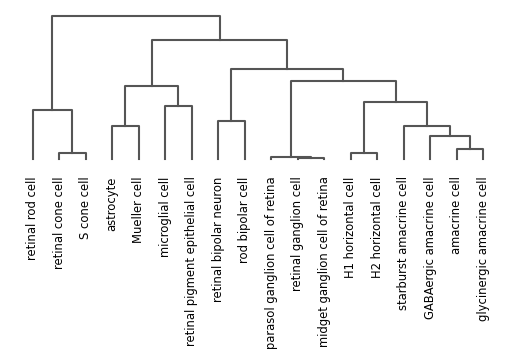

In [28]:
# full adata
if not adata.obsm or "X_pca" not in adata.obsm:
    sc.pp.pca(adata, random_state=seed)

ns.pp.dendrogram(adata, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

Saving dendrogram as...
../beckersv_output_retina/_cell_type.png


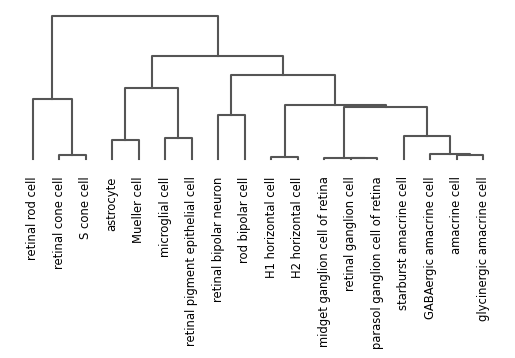

In [29]:
# subset adata
if not adata_subset.obsm or "X_pca" not in adata_subset.obsm:
    sc.pp.pca(adata_subset, random_state=seed)

ns.pp.dendrogram(adata_subset, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

#### Calculating cluster medians per gene

Run `ns.pp.prep_medians` before running NS-Forest.

**Note:** Do **not** run if evaluating marker lists. Do **not** run when generating scanpy plots (e.g. dot plot, violin plot, matrix plot). 

In [30]:
# full adata
adata = ns.pp.prep_medians(adata, cluster_header)
adata.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 18/18 [00:38<00:00,  2.14s/it]


Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.034
std: 0.216
Only positive genes selected. 8163 positive genes out of 35475 total genes
--- 41.569612979888916 seconds ---


,GABAergic amacrine cell,H1 horizontal cell,H2 horizontal cell,Mueller cell,S cone cell,amacrine cell,astrocyte,glycinergic amacrine cell,microglial cell,midget ganglion cell of retina,parasol ganglion cell of retina,retinal bipolar neuron,retinal cone cell,retinal ganglion cell,retinal pigment epithelial cell,retinal rod cell,rod bipolar cell,starburst amacrine cell
ENSG00000228794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.252475,0.233977,0.0,0.0,0.262665,0.0,0.0,0.0,0.0
ENSG00000188976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.302256,0.300208,0.0,0.0,0.302791,0.0,0.0,0.0,0.0
ENSG00000187642,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.243116,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
ENSG00000188290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.650110,0.242016,0.0,0.0,0.544794,0.0,0.0,0.0,0.0
ENSG00000078808,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.216748,0.205742,0.0,0.0,0.179138,0.0,0.0,0.0,0.0


In [31]:
# subset adata
adata_subset = ns.pp.prep_medians(adata_subset, cluster_header)
adata_subset.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 18/18 [00:14<00:00,  1.21it/s]


Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.002
std: 0.07
Only positive genes selected. 306 positive genes out of 15491 total genes
--- 15.817144870758057 seconds ---


,GABAergic amacrine cell,H1 horizontal cell,H2 horizontal cell,Mueller cell,S cone cell,amacrine cell,astrocyte,glycinergic amacrine cell,microglial cell,midget ganglion cell of retina,parasol ganglion cell of retina,retinal bipolar neuron,retinal cone cell,retinal ganglion cell,retinal pigment epithelial cell,retinal rod cell,rod bipolar cell,starburst amacrine cell
ENSG00000228794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.252475,0.233977,0.0,0.0,0.262665,0.0,0.0,0.0,0.0
ENSG00000228526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.228720,0.261106,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
ENSG00000231606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.294281,0.273392,0.0,0.0,0.257876,0.0,0.0,0.0,0.0
ENSG00000236810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.172577,0.156043,0.0,0.0,0.206334,0.0,0.0,0.0,0.0
ENSG00000228436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.405207,0.492236,0.0,0.0,0.446735,0.0,0.0,0.0,0.0


#### Calculating binary scores per gene per cluster

Run `ns.pp.prep_binary_scores` before running NS-Forest. Do not need to run if evaluating marker lists. Do not need to run when generating scanpy plots. 

In [32]:
# full adata
adata = ns.pp.prep_binary_scores(adata, cluster_header)
adata.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 18/18 [00:06<00:00,  2.61it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.147
std: 0.32
--- 6.9172139167785645 seconds ---


,GABAergic amacrine cell,H1 horizontal cell,H2 horizontal cell,Mueller cell,S cone cell,amacrine cell,astrocyte,glycinergic amacrine cell,microglial cell,midget ganglion cell of retina,parasol ganglion cell of retina,retinal bipolar neuron,retinal cone cell,retinal ganglion cell,retinal pigment epithelial cell,retinal rod cell,rod bipolar cell,starburst amacrine cell
ENSG00000228794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.886663,0.882353,0.0,0.0,0.891059,0.0,0.0,0.0,0.0
ENSG00000188976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.882752,0.882353,0.0,0.0,0.882959,0.0,0.0,0.0,0.0
ENSG00000187642,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
ENSG00000188290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.928807,0.882353,0.0,0.0,0.915045,0.0,0.0,0.0,0.0
ENSG00000078808,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.895547,0.889959,0.0,0.0,0.882353,0.0,0.0,0.0,0.0


In [33]:
# subset adata
adata_subset = ns.pp.prep_binary_scores(adata_subset, cluster_header)
adata_subset.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 18/18 [00:00<00:00, 74.04it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.122
std: 0.302
--- 0.2463529109954834 seconds ---


,GABAergic amacrine cell,H1 horizontal cell,H2 horizontal cell,Mueller cell,S cone cell,amacrine cell,astrocyte,glycinergic amacrine cell,microglial cell,midget ganglion cell of retina,parasol ganglion cell of retina,retinal bipolar neuron,retinal cone cell,retinal ganglion cell,retinal pigment epithelial cell,retinal rod cell,rod bipolar cell,starburst amacrine cell
ENSG00000228794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.886663,0.882353,0.0,0.0,0.891059,0.0,0.0,0.0,0.0
ENSG00000228526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.941176,0.948473,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
ENSG00000231606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.893805,0.885691,0.0,0.0,0.882353,0.0,0.0,0.0,0.0
ENSG00000236810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.887989,0.882353,0.0,0.0,0.906314,0.0,0.0,0.0,0.0
ENSG00000228436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.882353,0.898191,0.0,0.0,0.887821,0.0,0.0,0.0,0.0


#### Saving preprocessed AnnData as new h5ad

In [34]:
# full adata
filename = file.replace(".h5ad", "_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata.write_h5ad(filename)
adata

Saving new anndata object as...
../beckersv_data/nsf_retina_preprocessed.h5ad


AnnData object with n_obs × n_vars = 150000 × 8163
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'sample_collection_year', 'suspension_depletion_factors', 'suspension_depleted_cell_types', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_dissociation_time', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'cell_viability_percentage', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'cell_number_loaded', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id',

In [ ]:
# subset adata
filename = file.replace(".h5ad", f"_subset_{subset_gene}_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata_subset.write_h5ad(filename)
adata_subset

### Running NS-Forest

**Note:** Do not run NS-Forest if only evaluating input marker lists. 

In [36]:
# full adata
outputfilename_prefix = cluster_header
results = ns.nsforesting.NSForest(adata, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
results

Running NS-Forest version 4.1

Preparing adata...
Pre-selecting genes based on binary scores...
	BinaryFirst_high Threshold (mean + 2 * std): 0.787
	Average number of genes after gene_selection in each cluster: 1114.5555555555557
Saving number of genes selected per cluster as...
../beckersv_output_retina/cell_type_gene_selection.csv
--- 0.5974531173706055 seconds ---

Number of clusters to evaluate: 18
1 out of 18:
	astrocyte
	Pre-selected 135 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000131095', 'ENSG00000008394']
	fbeta: 0.778
	precision: 0.998
	recall: 0.413
2 out of 18:
	microglial cell
	Pre-selected 52 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000019582', 'ENSG00000204287']
	fbeta: 0.948
	precision: 0.978
	recall: 0.843
3 out of 18:
	amacrine cell
	Pre-selected 23 genes to feed into Random Forest.
	NSForest-selected markers: ['ENSG00000149571', 'ENSG00000182463']
	fbeta: 0.497
	precision: 0.86
	recall: 0.185
4 out of 18:
	ret

Calculating medians per cluster: 100%|██████████| 18/18 [00:01<00:00,  9.54it/s]


Saving supplementary table as...
../beckersv_output_retina/cell_type_markers_onTarget_supp.csv
Saving supplementary table as...
../beckersv_output_retina/cell_type_markers_onTarget.csv

Saving final results table as...
../beckersv_output_retina/cell_type_results.csv
Saving final results table as...
../beckersv_output_retina/cell_type_results.pkl


,software_version,cluster_header,clusterName,clusterSize,f_score,precision,recall,TN,FP,FN,TP,marker_count,NSForest_markers,binary_genes,onTarget
0,4.1,cell_type,astrocyte,1362,0.778054,0.998227,0.413363,148637,1,799,563,2,"[ENSG00000131095, ENSG00000008394]","[ENSG00000131095, ENSG00000196136, ENSG0000004...",1.000000
1,4.1,cell_type,microglial cell,1766,0.947771,0.978304,0.842582,148201,33,278,1488,2,"[ENSG00000019582, ENSG00000204287]","[ENSG00000019582, ENSG00000204287, ENSG0000017...",1.000000
2,4.1,cell_type,amacrine cell,796,0.496622,0.859649,0.184673,149180,24,649,147,2,"[ENSG00000149571, ENSG00000182463]","[ENSG00000149571, ENSG00000169946, ENSG0000018...",0.864164
3,4.1,cell_type,retinal cone cell,3247,0.771884,0.920750,0.468740,146622,131,1725,1522,2,"[ENSG00000114124, ENSG00000120500]","[ENSG00000271850, ENSG00000114124, ENSG0000024...",0.503749
4,4.1,cell_type,retinal rod cell,50276,0.965034,0.969003,0.949479,98197,1527,2540,47736,1,[ENSG00000132915],"[ENSG00000132915, ENSG00000185527, ENSG0000019...",1.000000
5,4.1,cell_type,Mueller cell,26702,0.959524,0.995465,0.838439,123196,102,4314,22388,2,"[ENSG00000156510, ENSG00000182256]","[ENSG00000156510, ENSG00000182256, ENSG0000016...",0.940290
6,4.1,cell_type,retinal ganglion cell,357,0.088409,0.236842,0.025210,149614,29,348,9,3,"[ENSG00000182197, ENSG00000152192, ENSG0000018...","[ENSG00000162545, ENSG00000182197, ENSG0000017...",0.336404
7,4.1,cell_type,retinal bipolar neuron,33058,0.797291,0.988556,0.449452,116770,172,18200,14858,2,"[ENSG00000101542, ENSG00000155307]","[ENSG00000101542, ENSG00000182348, ENSG0000012...",0.809757
8,4.1,cell_type,rod bipolar cell,8178,0.920263,0.982035,0.735265,141712,110,2165,6013,2,"[ENSG00000174788, ENSG00000165966]","[ENSG00000203727, ENSG00000174788, ENSG0000022...",1.000000
9,4.1,cell_type,retinal pigment epithelial cell,908,0.786554,0.894249,0.530837,149035,57,426,482,1,[ENSG00000230448],"[ENSG00000230448, ENSG00000118322, ENSG0000010...",1.000000


In [38]:
# subset adata
outputfilename_prefix_subset = cluster_header + "_subset_" + subset_gene
results_subset = ns.nsforesting.NSForest(adata_subset, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)
results_subset

Running NS-Forest version 4.1

Preparing adata...
Pre-selecting genes based on binary scores...
	BinaryFirst_high Threshold (mean + 2 * std): 0.727
	Average number of genes after gene_selection in each cluster: 37.05555555555556
Saving number of genes selected per cluster as...
../beckersv_output_retina/cell_type_subset_lncRNA_gene_selection.csv
--- 0.004734992980957031 seconds ---

Number of clusters to evaluate: 18
1 out of 18:
	astrocyte
	Pre-selected 9 genes to feed into Random Forest.
	Only 9 out of 15 top Random Forest features with median > 0 will be further evaluated.
	NSForest-selected markers: ['ENSG00000230490', 'ENSG00000227036']
	fbeta: 0.565
	precision: 0.878
	recall: 0.233
2 out of 18:
	microglial cell
	Pre-selected 0 genes to feed into Random Forest.
3 out of 18:
	amacrine cell
	Pre-selected 3 genes to feed into Random Forest.
	Only 3 out of 15 top Random Forest features with median > 0 will be further evaluated.
	NSForest-selected markers: ['ENSG00000245526', 'ENSG0000

Calculating medians per cluster: 100%|██████████| 18/18 [00:01<00:00, 16.39it/s]

Saving supplementary table as...
../beckersv_output_retina/cell_type_subset_lncRNA_markers_onTarget_supp.csv
Saving supplementary table as...
../beckersv_output_retina/cell_type_subset_lncRNA_markers_onTarget.csv

Saving final results table as...
../beckersv_output_retina/cell_type_subset_lncRNA_results.csv
Saving final results table as...
../beckersv_output_retina/cell_type_subset_lncRNA_results.pkl


,software_version,cluster_header,clusterName,clusterSize,f_score,precision,recall,TN,FP,FN,TP,marker_count,NSForest_markers,binary_genes,onTarget
0,4.1,cell_type,astrocyte,1362,0.564861,0.878116,0.232746,148594,44,1045,317,2,"[ENSG00000230490, ENSG00000227036]","[ENSG00000230490, ENSG00000253736, ENSG0000027...",0.863089
1,4.1,cell_type,amacrine cell,796,0.056545,0.048321,0.177136,146427,2777,655,141,3,"[ENSG00000245526, ENSG00000229989, ENSG0000025...","[ENSG00000245526, ENSG00000229989, ENSG0000025...",0.206314
2,4.1,cell_type,retinal cone cell,3247,0.747252,0.847938,0.506621,146458,295,1602,1645,1,[ENSG00000249364],"[ENSG00000271850, ENSG00000259221, ENSG0000024...",0.411512
3,4.1,cell_type,retinal rod cell,50276,0.903582,0.977367,0.694009,98916,808,15384,34892,1,[ENSG00000257165],"[ENSG00000257165, ENSG00000254951, ENSG0000022...",1.000000
4,4.1,cell_type,Mueller cell,26702,0.865201,0.919941,0.698862,121674,1624,8041,18661,1,[ENSG00000228740],"[ENSG00000228740, ENSG00000260372, ENSG0000023...",1.000000
5,4.1,cell_type,retinal ganglion cell,357,0.100026,0.088202,0.215686,148847,796,280,77,4,"[ENSG00000214870, ENSG00000234377, ENSG0000024...","[ENSG00000214870, ENSG00000234377, ENSG0000024...",0.521045
6,4.1,cell_type,retinal bipolar neuron,33058,0.612066,0.665049,0.464154,109214,7728,17714,15344,2,"[ENSG00000259481, ENSG00000248550]","[ENSG00000255580, ENSG00000259481, ENSG0000024...",0.181250
7,4.1,cell_type,rod bipolar cell,8178,0.871856,0.959090,0.639276,141599,223,2950,5228,2,"[ENSG00000227681, ENSG00000264630]","[ENSG00000227681, ENSG00000286961, ENSG0000026...",1.000000
8,4.1,cell_type,retinal pigment epithelial cell,908,0.786554,0.894249,0.530837,149035,57,426,482,1,[ENSG00000230448],[ENSG00000230448],1.000000
9,4.1,cell_type,S cone cell,219,0.383305,0.489130,0.205479,149734,47,174,45,5,"[ENSG00000250592, ENSG00000261460, ENSG0000025...","[ENSG00000250592, ENSG00000261460, ENSG0000023...",1.000000


### Visualization (Preprocessing)

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_retina/histogram_medians_cell_type.png


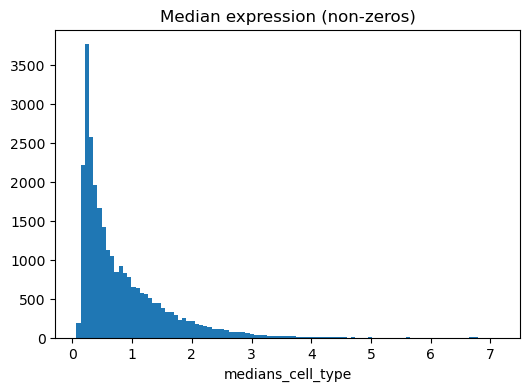

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_retina/histogram_medians_cell_type.png


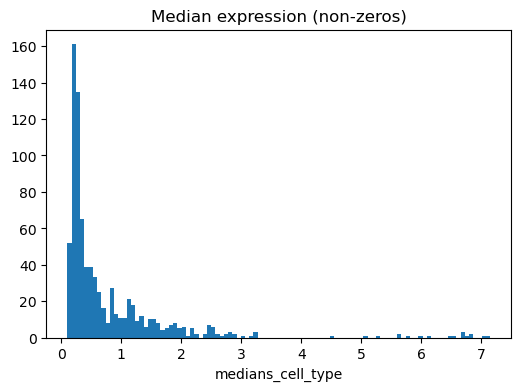

In [39]:
ns.pp.plot_varm(adata, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_retina/histogram_medians_cell_type.png


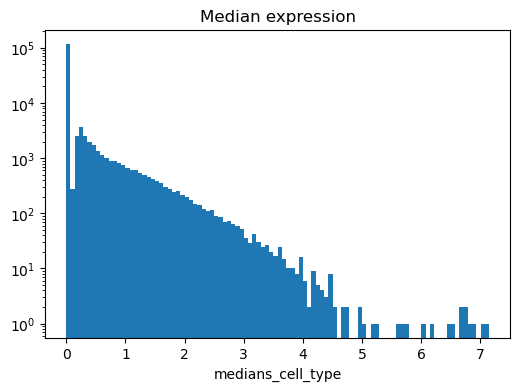

Saving adata.varm[medians_cell_type] as histogram as...
../beckersv_output_retina/histogram_medians_cell_type.png


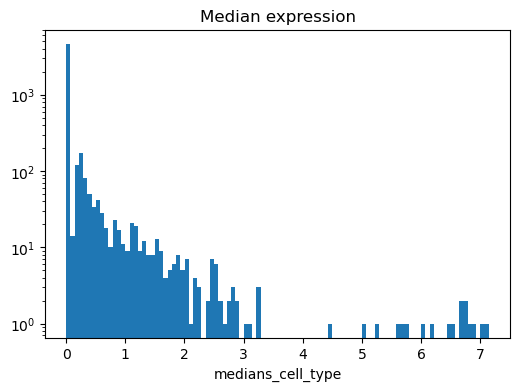

In [40]:
ns.pp.plot_varm(adata, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_retina/histogram_binary_scores_cell_type.png


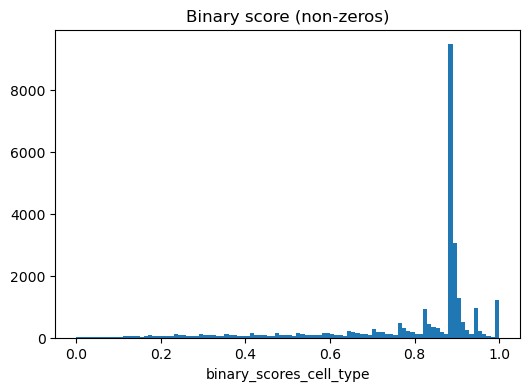

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_retina/histogram_binary_scores_cell_type.png


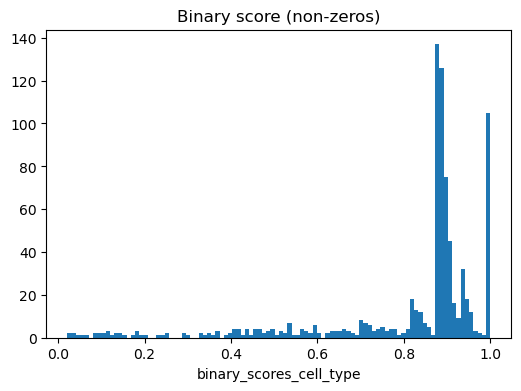

In [41]:
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_retina/histogram_binary_scores_cell_type.png


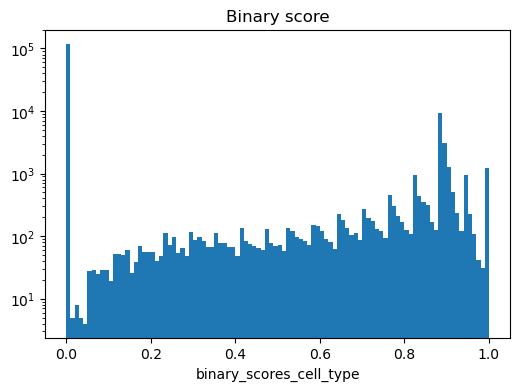

Saving adata.varm[binary_scores_cell_type] as histogram as...
../beckersv_output_retina/histogram_binary_scores_cell_type.png


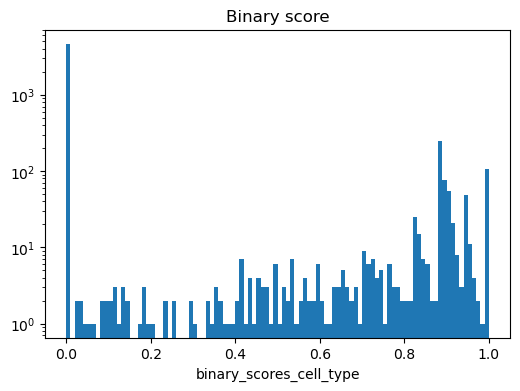

In [42]:
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

### Visualization (Results): Plotting scanpy dot plot, violin plot, matrix plot for NS-Forest markers

**Note:** Assign pre-defined dendrogram order here **or** use `adata.uns["dendrogram_" + cluster_header]["categories_ordered"]`. 

In [43]:
to_plot = results.copy()
to_plot_subset = results_subset.copy()

In [44]:
# full adata
dendrogram = [] # custom dendrogram order
dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot["clusterName"] = to_plot["clusterName"].astype("category")
to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
to_plot = to_plot.sort_values("clusterName")
to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})

In [45]:
# subset adata
dendrogram_subset = [] # custom dendrogram order
dendrogram_subset = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].astype("category")
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].cat.set_categories(dendrogram_subset)
to_plot_subset = to_plot_subset.sort_values("clusterName")
to_plot_subset = to_plot_subset.rename(columns = {"NSForest_markers": "markers"})

In [46]:
# full adata
markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
markers_dict

{'retinal rod cell': ['ENSG00000132915'],
 'retinal cone cell': ['ENSG00000114124', 'ENSG00000120500'],
 'S cone cell': ['ENSG00000128617', 'ENSG00000249364'],
 'astrocyte': ['ENSG00000131095', 'ENSG00000008394'],
 'Mueller cell': ['ENSG00000156510', 'ENSG00000182256'],
 'microglial cell': ['ENSG00000019582', 'ENSG00000204287'],
 'retinal pigment epithelial cell': ['ENSG00000230448'],
 'retinal bipolar neuron': ['ENSG00000101542', 'ENSG00000155307'],
 'rod bipolar cell': ['ENSG00000174788', 'ENSG00000165966'],
 'parasol ganglion cell of retina': ['ENSG00000169302',
  'ENSG00000170231',
  'ENSG00000197177'],
 'retinal ganglion cell': ['ENSG00000182197',
  'ENSG00000152192',
  'ENSG00000185567'],
 'midget ganglion cell of retina': ['ENSG00000085831',
  'ENSG00000150722',
  'ENSG00000173267'],
 'H1 horizontal cell': ['ENSG00000157890', 'ENSG00000169933'],
 'H2 horizontal cell': ['ENSG00000102290', 'ENSG00000136842'],
 'starburst amacrine cell': ['ENSG00000115665'],
 'GABAergic amacrine ce

In [47]:
# subset adata
markers_dict_subset = dict(zip(to_plot_subset["clusterName"], to_plot_subset["markers"]))
markers_dict_subset

{'retinal rod cell': ['ENSG00000257165'],
 'retinal cone cell': ['ENSG00000249364'],
 'S cone cell': ['ENSG00000250592',
  'ENSG00000261460',
  'ENSG00000250994',
  'ENSG00000249364',
  'ENSG00000259221'],
 'astrocyte': ['ENSG00000230490', 'ENSG00000227036'],
 'Mueller cell': ['ENSG00000228740'],
 'retinal pigment epithelial cell': ['ENSG00000230448'],
 'retinal bipolar neuron': ['ENSG00000259481', 'ENSG00000248550'],
 'rod bipolar cell': ['ENSG00000227681', 'ENSG00000264630'],
 'parasol ganglion cell of retina': ['ENSG00000227115',
  'ENSG00000232044',
  'ENSG00000286214'],
 'retinal ganglion cell': ['ENSG00000214870',
  'ENSG00000234377',
  'ENSG00000245694',
  'ENSG00000271945'],
 'midget ganglion cell of retina': ['ENSG00000257398', 'ENSG00000239911'],
 'H1 horizontal cell': ['ENSG00000224020'],
 'H2 horizontal cell': ['ENSG00000244040', 'ENSG00000235688'],
 'starburst amacrine cell': ['ENSG00000240922',
  'ENSG00000242808',
  'ENSG00000253554'],
 'GABAergic amacrine cell': ['ENSG0

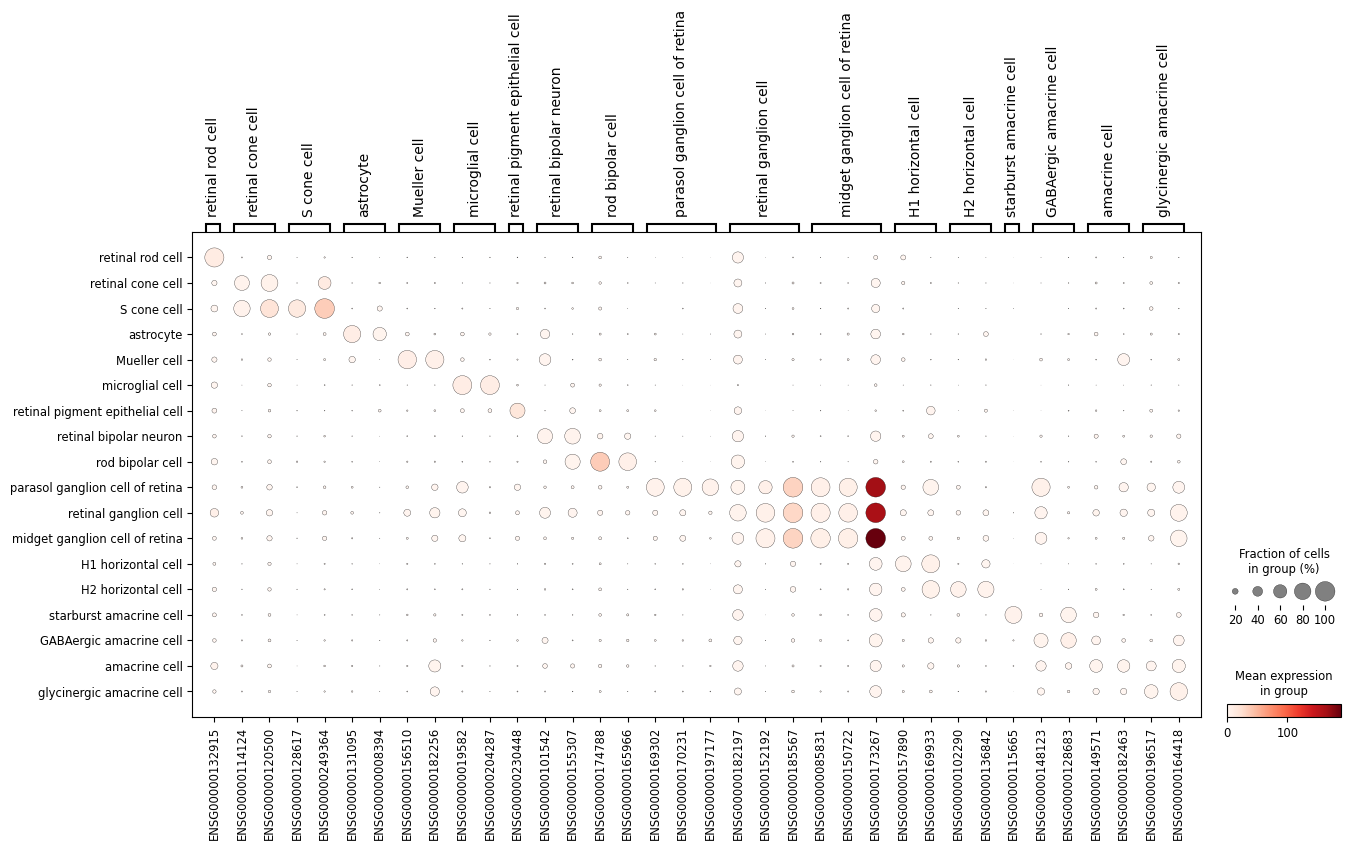

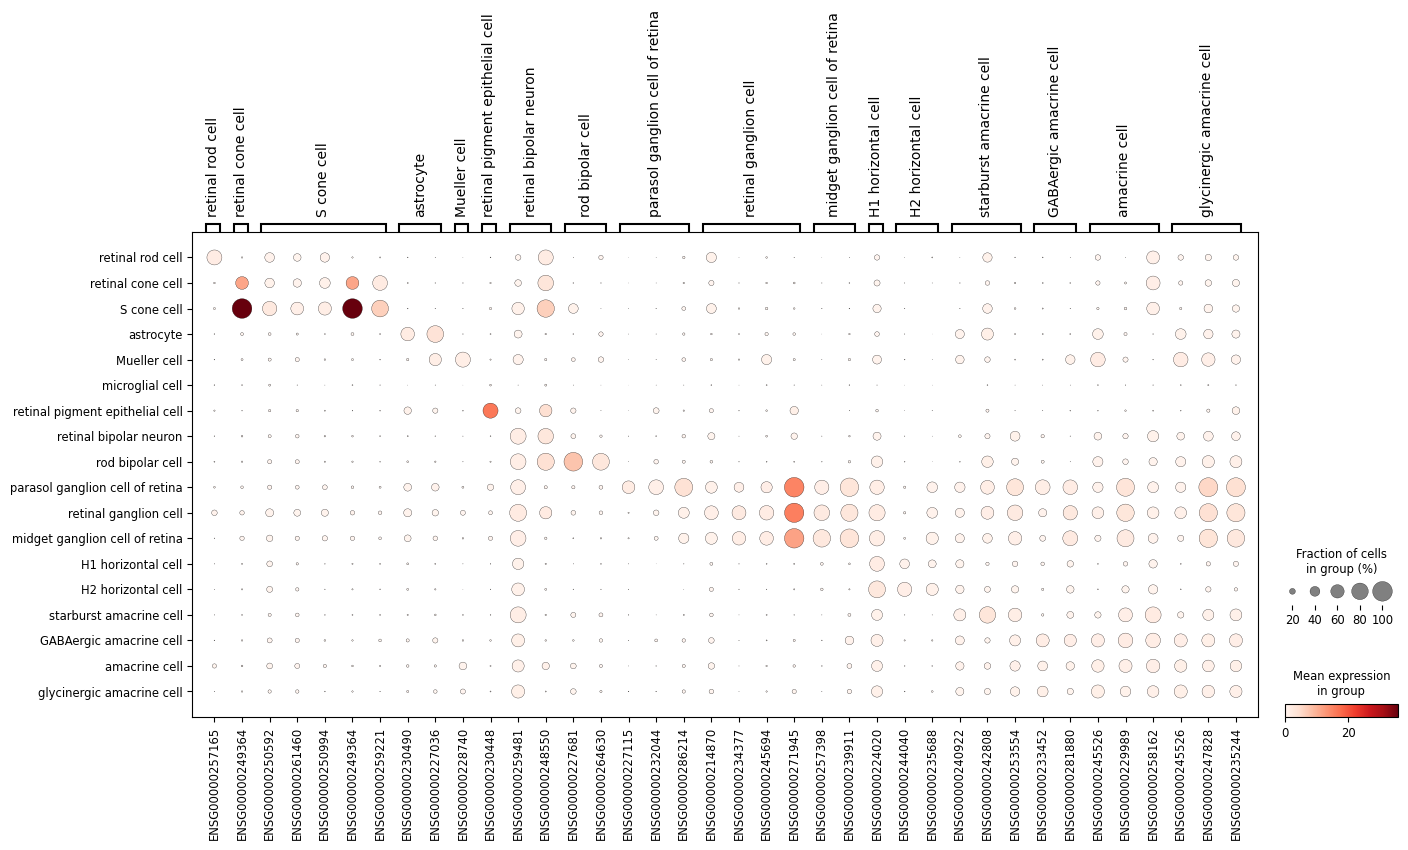

In [48]:
ns.pl.dotplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.dotplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

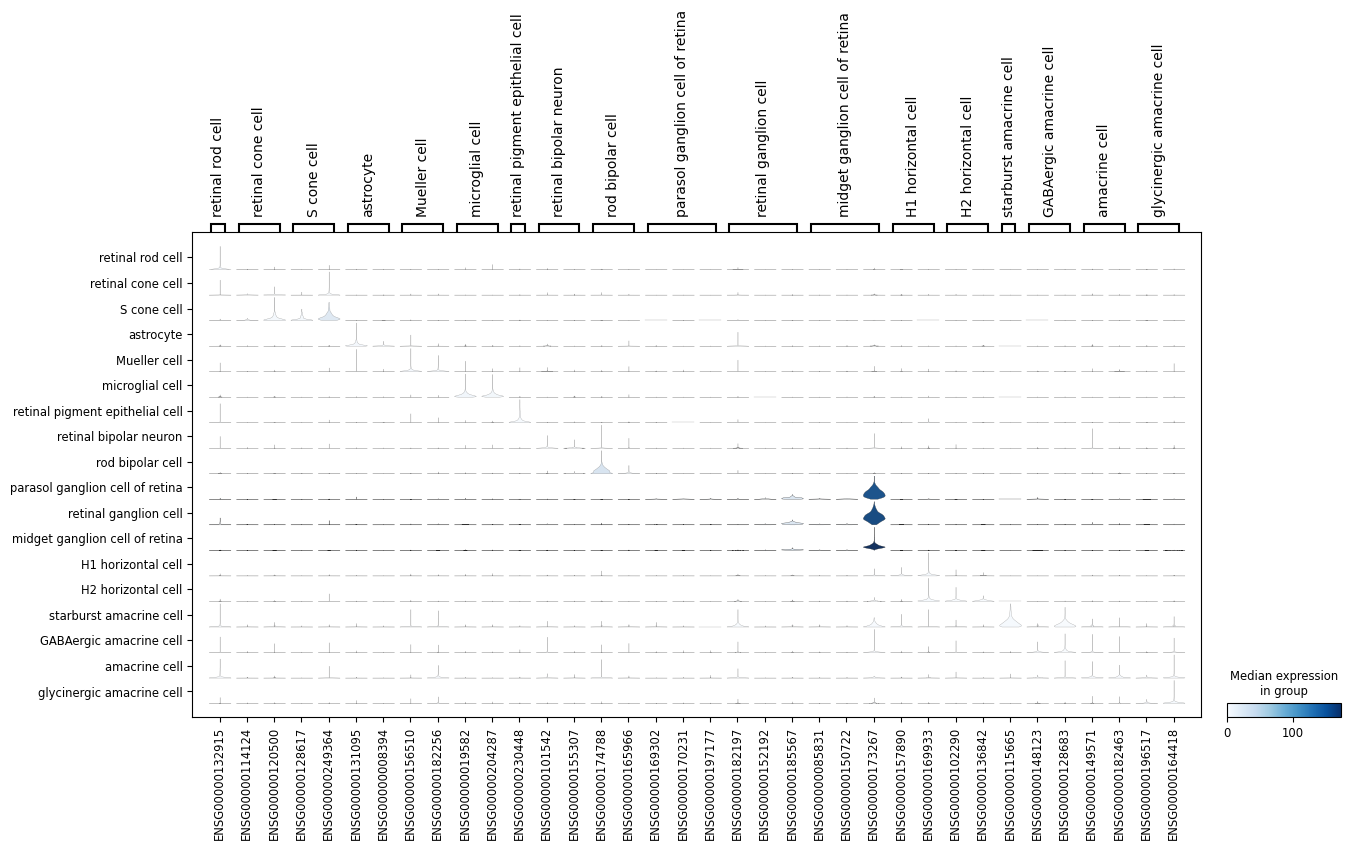

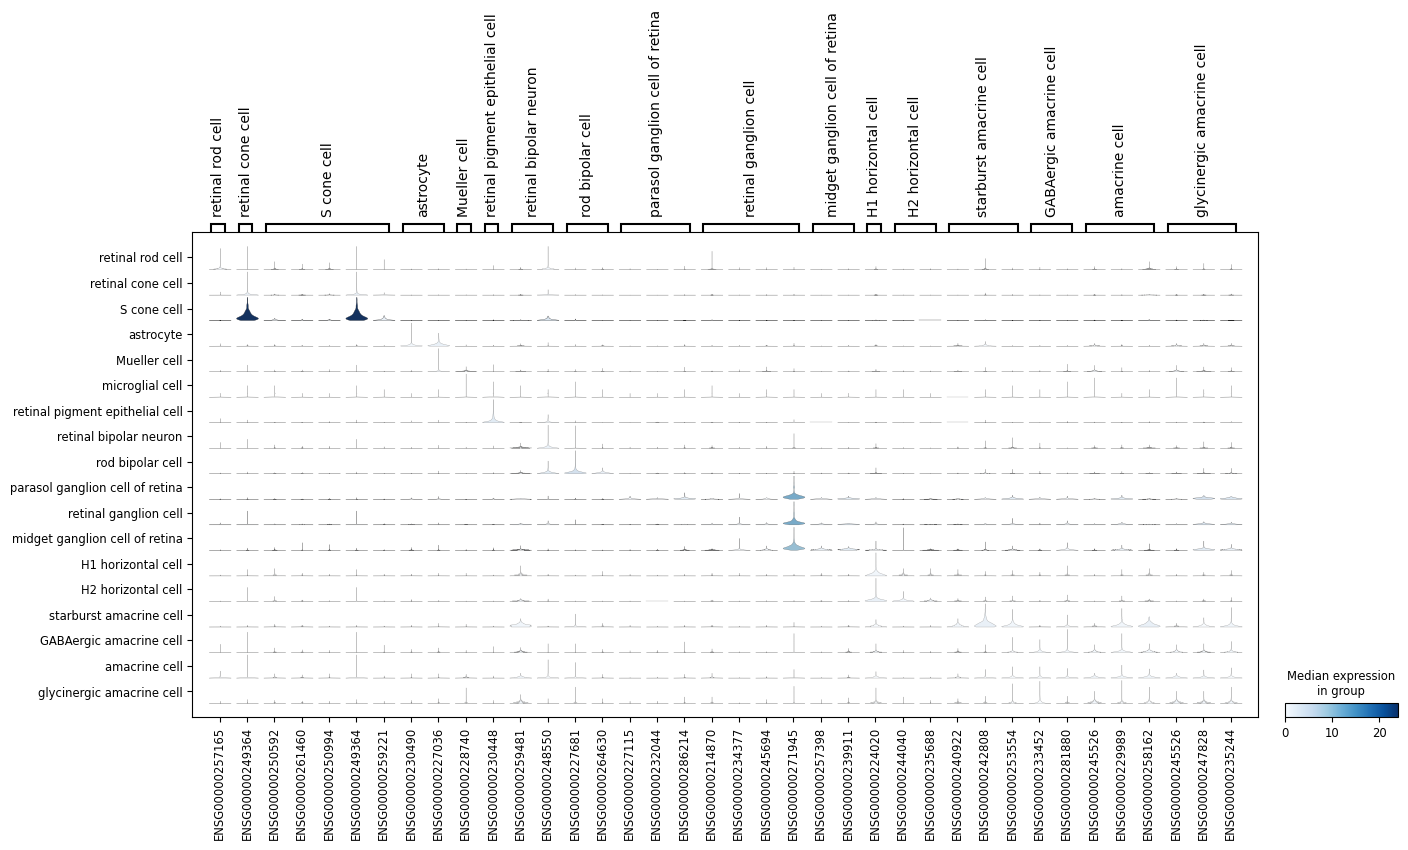

In [49]:
ns.pl.stackedviolin(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.stackedviolin(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

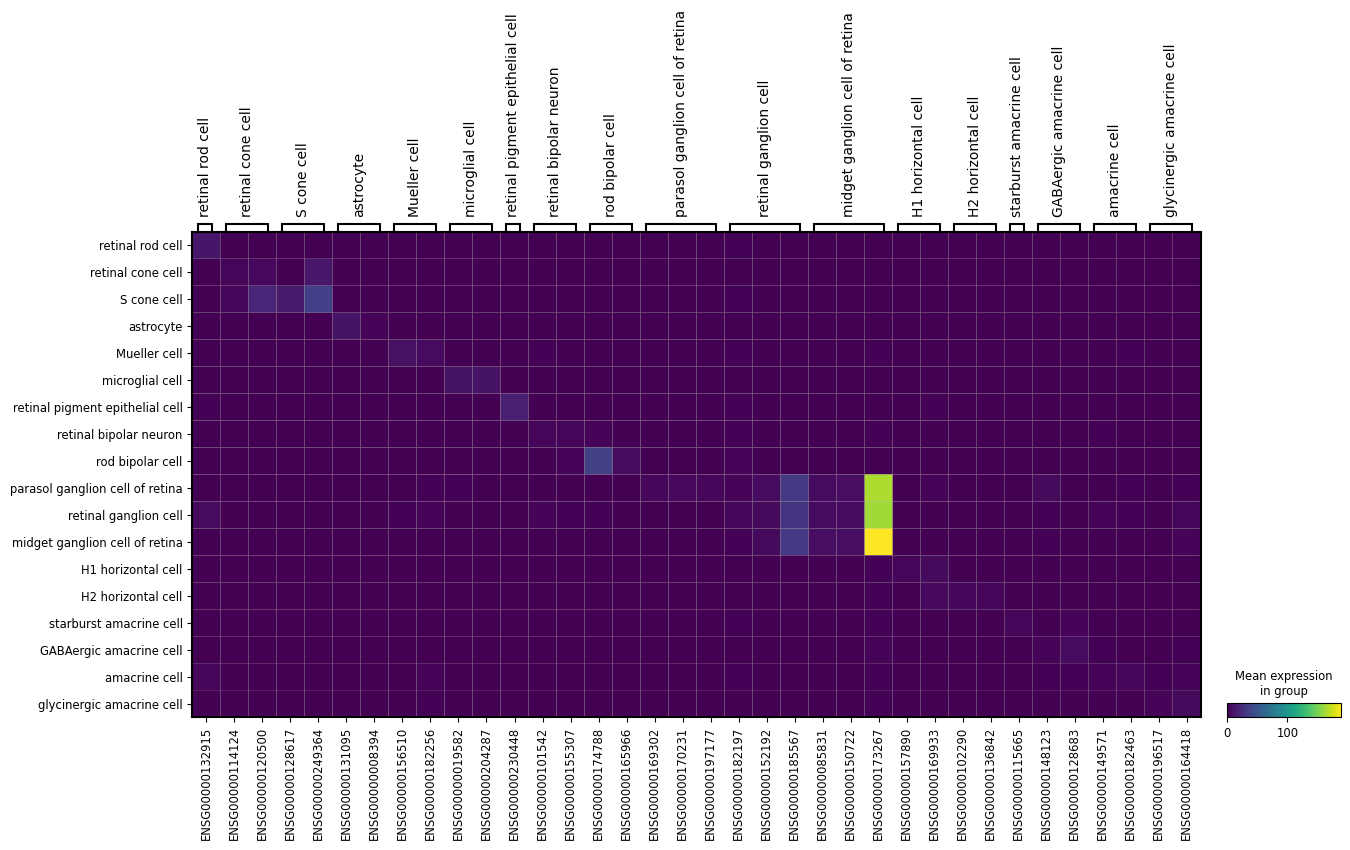

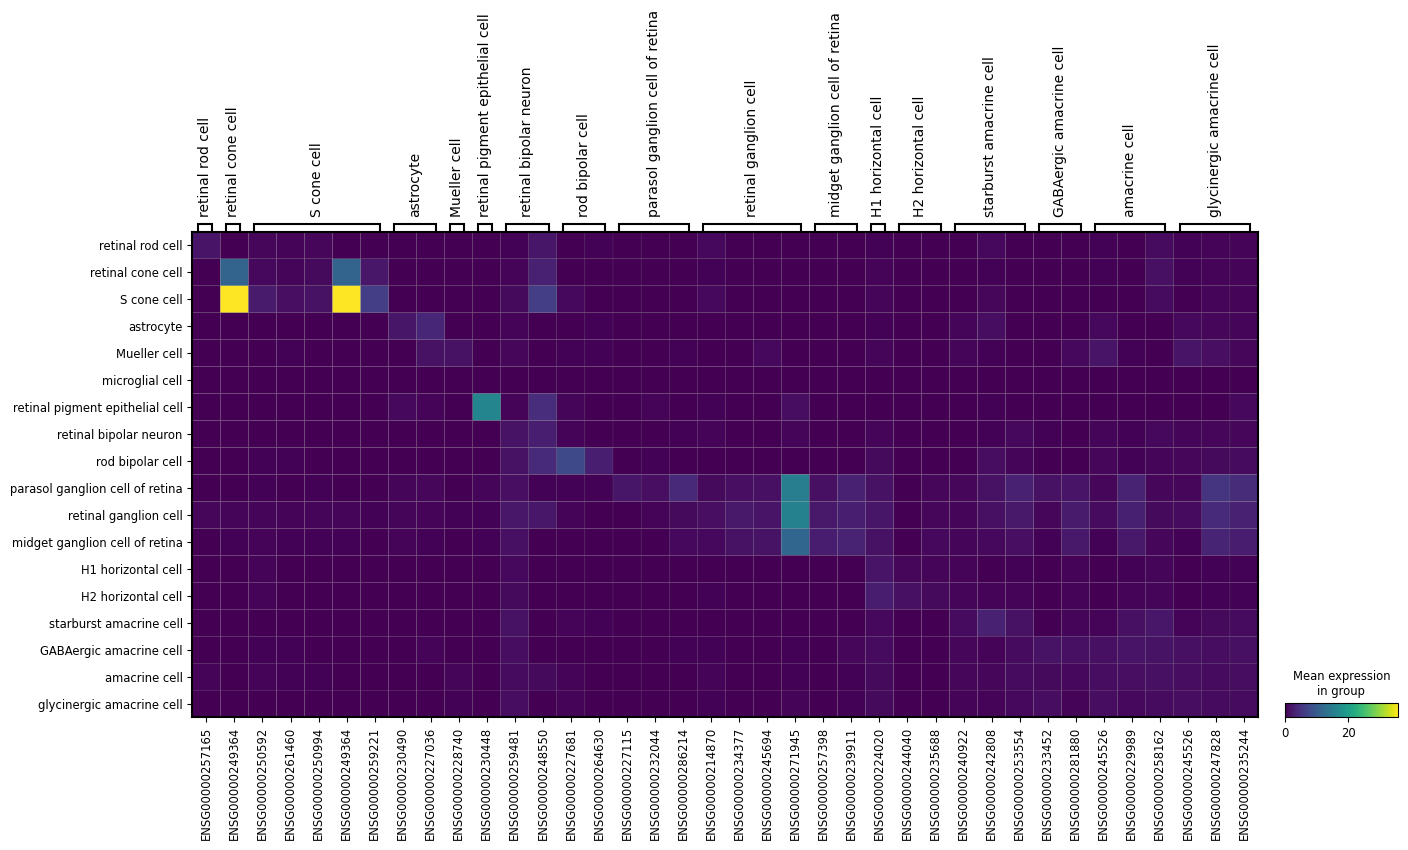

In [50]:
ns.pl.matrixplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.matrixplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

#### Plotting classification metrics from NS-Forest results

In [51]:
ns.pl.boxplot(results, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_retina/cell_type_boxplot_f_score_precision_recall_onTarget.html
Saving...
 ../beckersv_output_retina/cell_type_subset_lncRNA_boxplot_f_score_precision_recall_onTarget.html


#### Plotting individual classification metrics

In [52]:
ns.pl.boxplot(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_retina/cell_type_boxplot_f_score.html
Saving...
 ../beckersv_output_retina/cell_type_subset_lncRNA_boxplot_f_score.html


#### Plotting metrics vs clusterSize

In [53]:
ns.pl.scatter_w_clusterSize(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_retina/cell_type_scatter_f_score.html
Saving...
 ../beckersv_output_retina/cell_type_subset_lncRNA_scatter_f_score.html


In [54]:
ns.pl.scatter_w_clusterSize(results, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_retina/cell_type_scatter_precision.html
Saving...
 ../beckersv_output_retina/cell_type_subset_lncRNA_scatter_precision.html


In [55]:
ns.pl.scatter_w_clusterSize(results, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_retina/cell_type_scatter_recall.html
Saving...
 ../beckersv_output_retina/cell_type_subset_lncRNA_scatter_recall.html


In [56]:
ns.pl.scatter_w_clusterSize(results, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

Saving...
 ../beckersv_output_retina/cell_type_scatter_onTarget.html
Saving...
 ../beckersv_output_retina/cell_type_subset_lncRNA_scatter_onTarget.html
